In [40]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import yfinance as yf

In [95]:
data = yf.download('^GSPC', start='2025-03-27', end='2026-04-25', auto_adjust=False)
data['log_return'] = (data['Adj Close'] / data['Adj Close'].shift(1)).apply(lambda x: np.log(x))
data['cumulative_log_return'] = data['log_return'].cumsum()
data = data.fillna(0)

[*********************100%***********************]  1 of 1 completed


In [96]:
data

Price,Adj Close,Close,High,Low,Open,Volume,log_return,cumulative_log_return
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,,
Date,,,,,,,,
2025-03-27,5693.310059,5693.310059,5732.279785,5670.939941,5695.640137,4403460000,0.000000,0.000000
2025-03-28,5580.939941,5580.939941,5685.890137,5572.419922,5679.200195,4513330000,-0.019935,-0.019935
2025-03-31,5611.850098,5611.850098,5627.560059,5488.729980,5527.910156,5257250000,0.005523,-0.014411
2025-04-01,5633.069824,5633.069824,5650.569824,5558.520020,5597.529785,4434500000,0.003774,-0.010637
2025-04-02,5670.970215,5670.970215,5695.310059,5571.479980,5580.759766,4243830000,0.006706,-0.003932
...,...,...,...,...,...,...,...,...
2026-04-20,7109.140137,7109.140137,7122.649902,7084.410156,7117.049805,4661130000,-0.002377,0.222089
2026-04-21,7064.009766,7064.009766,7137.270020,7050.200195,7122.640137,5160270000,-0.006368,0.215721


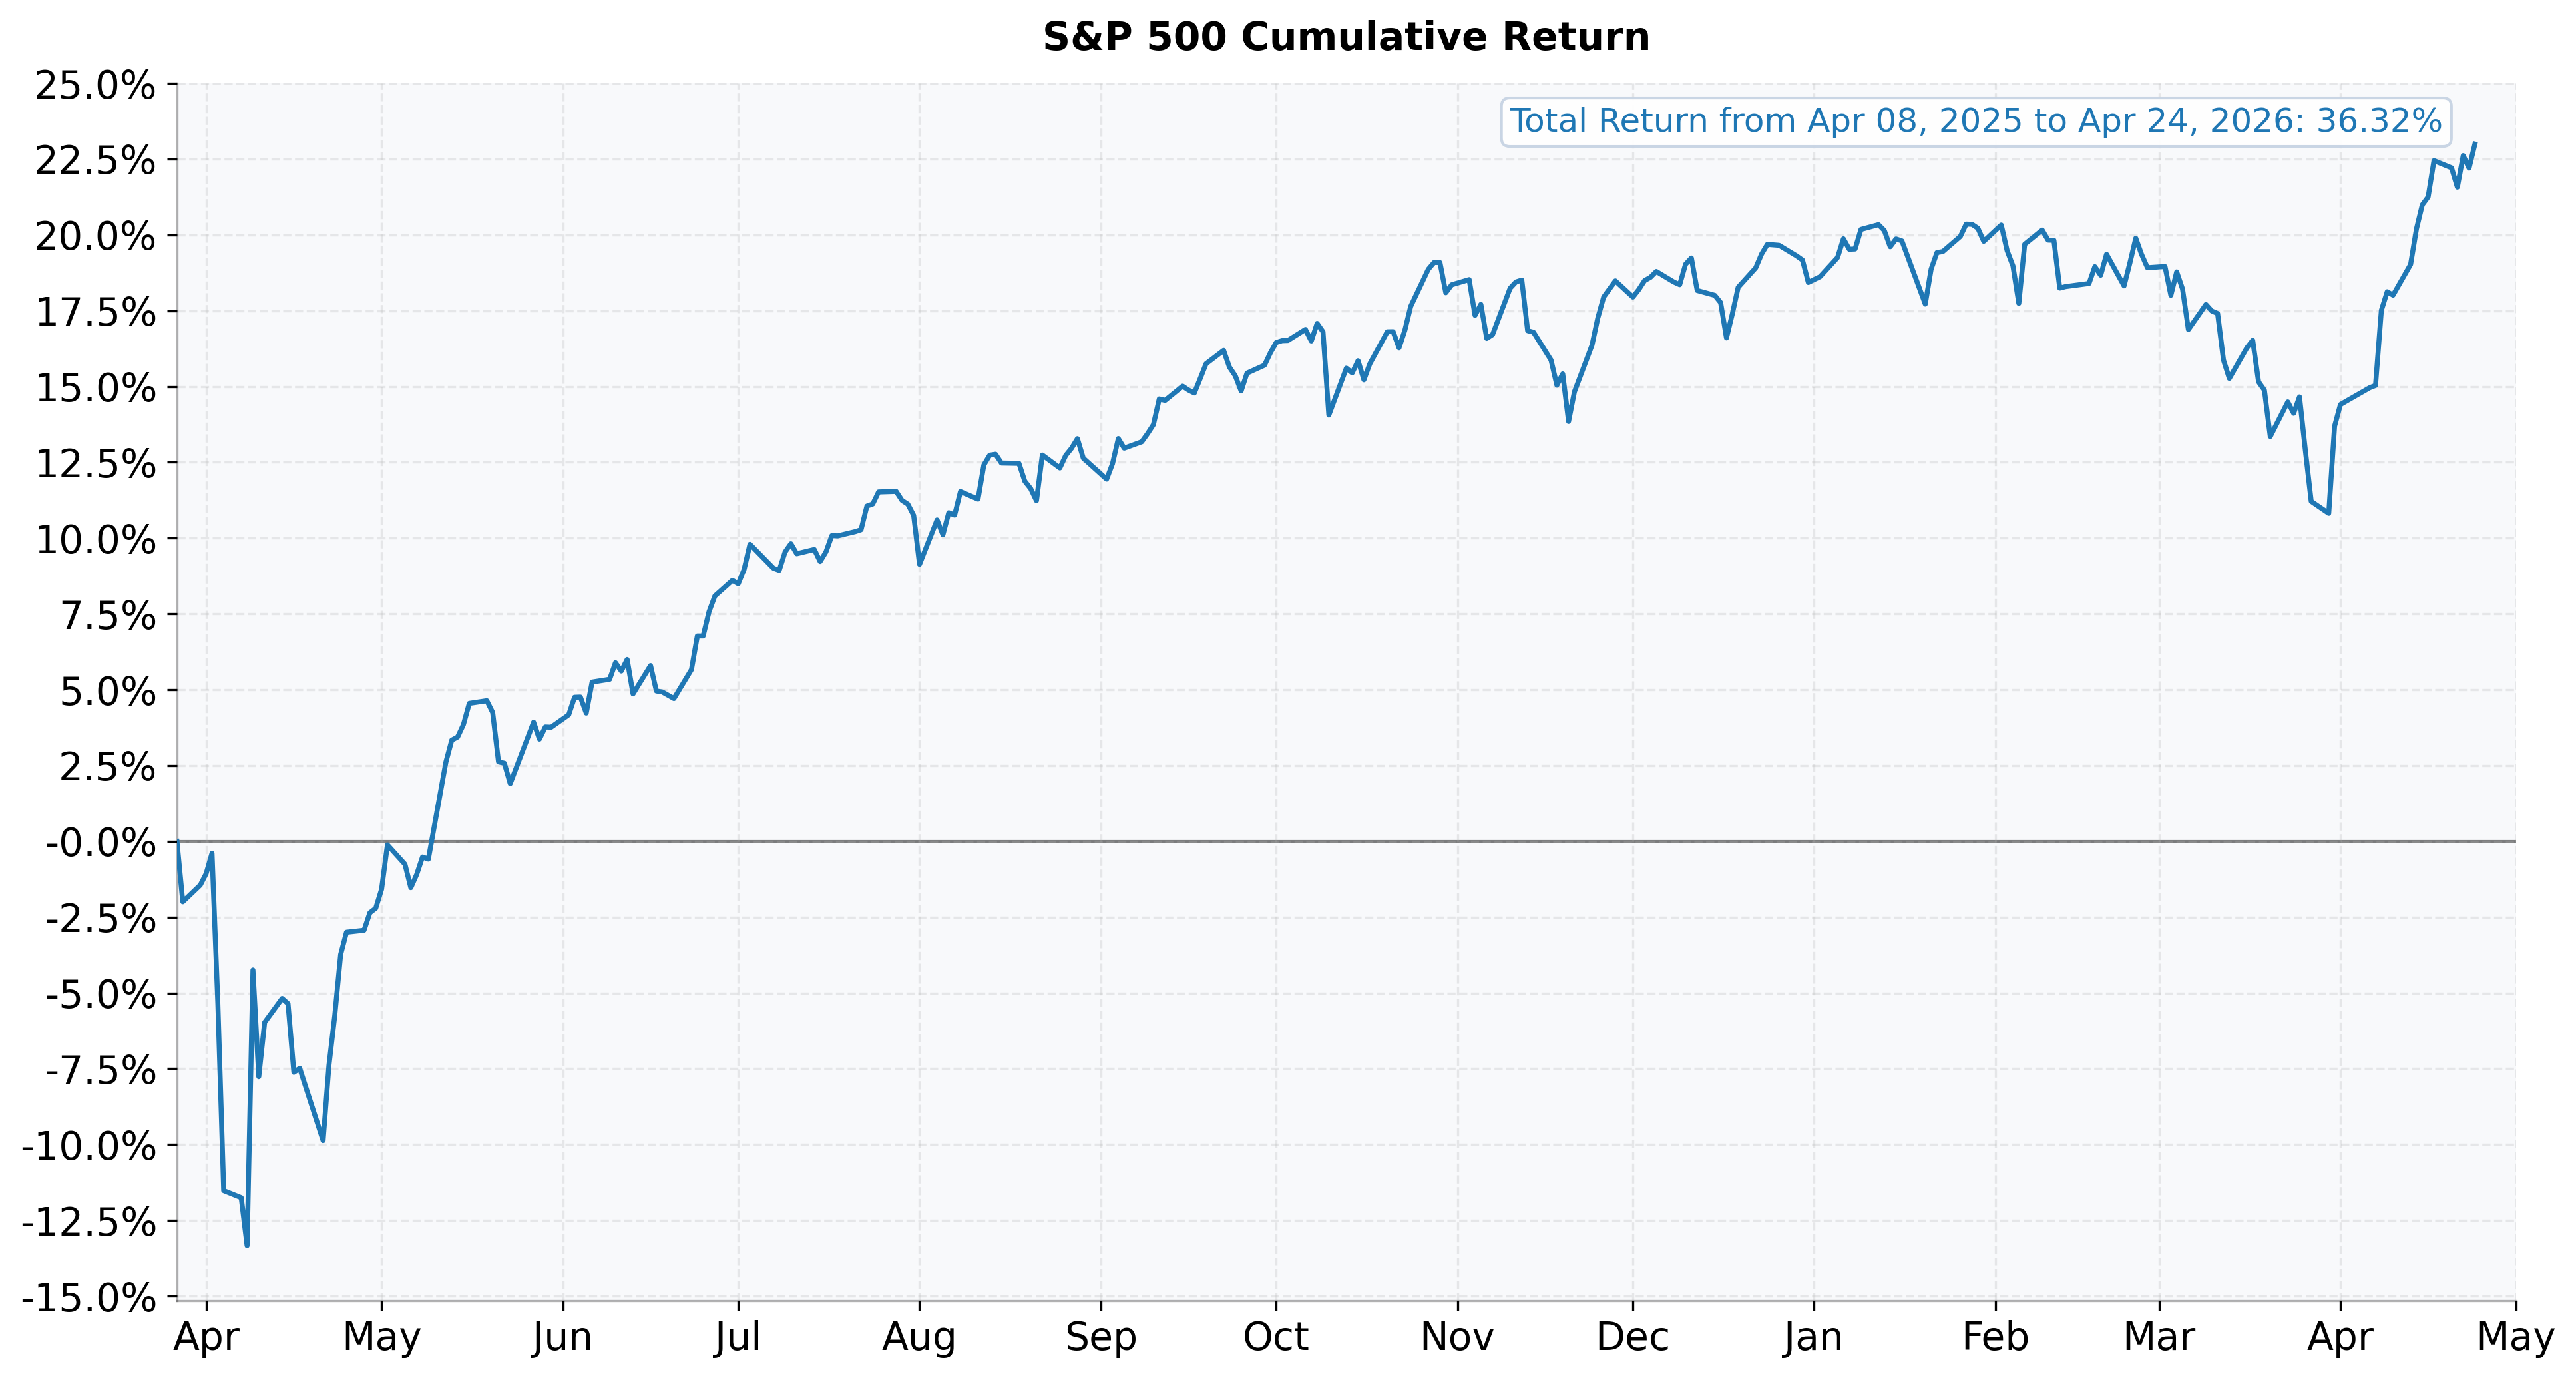

In [109]:
data['log_return'] = (data['Adj Close'] / data['Adj Close'].shift(1)).apply(lambda x: np.log(x))
data['cumulative_log_return'] = data['log_return'].cumsum()

fig, ax = plt.subplots(figsize=(13, 7), dpi=300)

# Style 
ax.set_facecolor('#f8f9fb')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_alpha(0.3)
ax.spines['bottom'].set_alpha(0.3)

# Main series
ax.plot(
    data.index,
    data['cumulative_log_return'],
    color='#1f77b4',
    linewidth=1.8,
    zorder=3,
    label='Cumulative Log Return',
)

# Zero baseline
ax.axhline(0, color='black', linewidth=1.0, alpha=0.5, zorder=1)

# Highlight and annotate latest value
end_x = data.index[-1]
end_y = data['cumulative_log_return'].iloc[-1]
min_y = data['cumulative_log_return'].min()
max_y = data['cumulative_log_return'].max()
min_y_index = int(np.nanargmin(data['cumulative_log_return'].to_numpy()))
max_y_index = int(np.nanargmax(data['cumulative_log_return'].to_numpy()))

ax.annotate(
    f"Total Return from {data.index[min_y_index].strftime('%b %d, %Y')} to {data.index[max_y_index].strftime('%b %d, %Y')}: {max_y-min_y:.2%}" if abs(end_y) < 1 else f"Latest: {end_y:.2f}",
    xy=(end_x-dt.timedelta(days=120), end_y-0.005),
    xytext=(-95, 10),
    textcoords='offset points',
    fontsize=12,
    color='#1f77b4',
    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#c7d3e3', alpha=0.95),
)

# Labels and title
ax.set_title('S&P 500 Cumulative Return', fontsize=14, weight='semibold', pad=12)
ax.set_yticks(np.arange(-0.15, 0.275, 0.025))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
ax.tick_params(axis='both', which='major', labelsize=14)
ax.set_xlim(data.index[0], end_x + pd.Timedelta(days=7))
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))

# Grid and legend
ax.grid(axis='y', linestyle='--', alpha=0.25)
ax.grid(axis='x', linestyle='--', alpha=0.25)


plt.tight_layout()
plt.show()

In [ ]:
# plot a subset of random paths along with the steady growth path
months = sim_paths['Months']
paths_df = sim_paths.drop(columns=['Months', 'Index Value'])
results = sim_paths[['Months', 'Index Value']]
# Show a small representative subset of random paths
num_paths_to_plot = max(1, int(NUM_PATHS * 0.001))
sampled_cols = paths_df.columns[:num_paths_to_plot]
fig, ax = plt.subplots(figsize=(13, 7), dpi=600)
# Clean visual style
ax.set_facecolor('#f8f9fb')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_alpha(0.3)
ax.spines['bottom'].set_alpha(0.3)
# Plot random paths in muted gray
for col in sampled_cols:
    # gradient color by path order
    idx = sampled_cols.get_loc(col)
    denom = max(len(sampled_cols) - 1, 1)
    line_color = plt.cm.binary(idx / denom)
    ax.plot(
        months,
        paths_df[col],
        color=line_color,
        alpha=0.30,
        linewidth=SECONDARY_LINE_WIDTH,
        zorder=1,
    )
# Plot steady growth path prominently
ax.plot(
    results['Months'],
    results['Index Value'],
    label='Steady Growth Benchmark',
    color='#1f77b4',
    linewidth=PRIMARY_LINE_WIDTH,
    zorder=3,
)
# Highlight end point of steady path
end_x = results['Months'].iloc[-1]
end_y = results['Index Value'].iloc[-1]
ax.scatter([end_x], [end_y], color='#1f77b4', s=36, zorder=4)
ax.annotate(
    f"Final Index Value: ${end_y:,.2f}",
    xy=(240, 11800),
    xytext=(-90, 10),
    textcoords='offset points',
    fontsize=NOTE_FONT_SIZE,
    color='#1f77b4',
    bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#c7d3e3', alpha=0.95),
)
ax.set_xlabel('Months', fontsize=AXES_FONT_SIZE)
ax.set_ylabel('Index Value ($)', fontsize=AXES_FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE)
ax.set_title(
    f'Index Growth Over {ACCUMULATION_LENGTH} Years\nSteady Path & Simulated Paths',
    fontsize=TITLE_FONT_SIZE,
    weight='semibold',
    pad=12,
)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_yticks(range(int(np.min(results['Index Value']) // 1000) * 1000, int(np.max(results['Index Value'])) + 4000, 2000))
ax.set_xticks(range(0, int(results['Months'].max()) + 1, 60))
ax.grid(axis='y', linestyle='--', alpha=0.25)
ax.grid(axis='x', linestyle=':', alpha=0.10)
ax.set_xlim(left=0)
ax.legend(
    loc='upper left',
    frameon=True,
    fontsize=LEGEND_FONT_SIZE,
    framealpha=0.95,
    facecolor='white',
    edgecolor='#d9dde3',
)
fig.text(
    0.01,
    0.01,
    f"Showing {num_paths_to_plot:,} of {NUM_PATHS:,} simulated paths",
    fontsize=NOTE_FONT_SIZE,
    color='#6b7280',
)
plt.tight_layout()
plt.show()